# Desafio Wellbe — ETL

Extração, tratamento e carga de `data/dados.csv` em MySQL.

In [1]:
import re
import pandas as pd

RAW_PATH = "../data/dados.csv"

raw = pd.read_csv(RAW_PATH, skiprows=13, encoding="utf-8")

colunas_esperadas = {
    "Código": "codigo",
    "Custo do afastamento": "custo_raw",
    "Identificação": "identificacao_raw",
    "Funcionário": "funcionario_raw",
    "Departamento": "departamento_raw",
    "Data do Atestado": "data_raw",
    "Especialidade": "especialidade_raw",
    "Motivo": "motivo_raw",
    "Líder": "lider_raw",
}
assert set(colunas_esperadas.keys()) <= set(raw.columns), (
    f"Header inesperado: {raw.columns.tolist()}"
)
raw = raw.rename(columns=colunas_esperadas)

print(raw.shape)
raw.head()

(91, 9)


,codigo,custo_raw,identificacao_raw,funcionario_raw,departamento_raw,data_raw,especialidade_raw,motivo_raw,lider_raw
0,1036743,"20,4",NaN,Anonimo 101,Gerente,29/05/2019,Exames,Exames,Sim
1,1036742,23,NaN,Anonimo 1,ASSISTENTE DE IMPLANTACAO,23/05/2019,Neurologia pediátrica,Acompanhamento familiar,NaN
2,1036741,"22,8",NaN,Anonimo 1,ASSISTENTE DE IMPLANTACAO,17/05/2019,NaN,Consulta médica,NaN
3,1036740,–-,NaN,Anonimo 1,ASSISTENTE DE IMPLANTACAO,16/05/2019,Exames,Exames,NaN
4,1036739,22,NaN,Anonimo 1,ASSISTENTE DE IMPLANTACAO,06/05/2019,NaN,Consulta médica,NaN


In [2]:
def parse_custo(value):
    if pd.isna(value):
        return 0.0
    text = str(value).strip().replace(",", ".")
    if re.fullmatch(r"-?\d+(\.\d+)?", text):
        return float(text)
    return 0.0


def parse_data(value):
    if pd.isna(value) or str(value).strip() == "":
        return pd.NaT
    return pd.to_datetime(str(value).strip(), format="%d/%m/%Y", errors="coerce")


# Sanidade das regras de tratamento (DADOS.md)
assert parse_custo("20,4") == 20.4
assert parse_custo("--") == 0.0
assert parse_custo("–-") == 0.0
assert parse_custo(float("nan")) == 0.0
assert parse_custo("9215") == 9215.0  # valor bruto quebrado, tratado literalmente
assert parse_data("29/05/2019") == pd.Timestamp("2019-05-29")
assert pd.isna(parse_data(""))
assert pd.isna(parse_data(float("nan")))
print("helpers ok")

helpers ok


In [3]:
def transform(raw_df):
    departamentos = {}
    funcionarios = {}
    atestados = []
    lider_atual = None

    def dep_id(nome_raw):
        nome = str(nome_raw).strip() if pd.notna(nome_raw) else ""
        if nome == "":
            return None
        if nome not in departamentos:
            departamentos[nome] = len(departamentos) + 1
        return departamentos[nome]

    def func_id(nome_raw, eh_lider_linha):
        nome = str(nome_raw).strip()
        if nome not in funcionarios:
            funcionarios[nome] = {"id": len(funcionarios) + 1, "eh_lider": False}
        if eh_lider_linha:
            funcionarios[nome]["eh_lider"] = True
        return funcionarios[nome]["id"]

    for _, row in raw_df.iterrows():
        nome_funcionario = row["funcionario_raw"]
        if pd.isna(nome_funcionario) or str(nome_funcionario).strip() == "":
            continue

        eh_lider_linha = str(row["lider_raw"]).strip().lower() == "sim"
        funcionario_id = func_id(nome_funcionario, eh_lider_linha)

        if eh_lider_linha:
            lider_atual = str(nome_funcionario).strip()

        data = parse_data(row["data_raw"])
        if pd.isna(data):
            continue

        departamento_id = dep_id(row["departamento_raw"])
        lider_funcionario_id = (
            funcionarios[lider_atual]["id"] if lider_atual is not None else None
        )

        atestados.append({
            "id": int(row["codigo"]),
            "funcionario_id": funcionario_id,
            "departamento_id": departamento_id,
            "lider_funcionario_id": lider_funcionario_id,
            "data_atestado": data.date(),
            "especialidade": str(row["especialidade_raw"]).strip() if pd.notna(row["especialidade_raw"]) else "",
            "motivo": str(row["motivo_raw"]).strip() if pd.notna(row["motivo_raw"]) else "",
            "custo_afastamento": parse_custo(row["custo_raw"]),
        })

    return departamentos, funcionarios, atestados


departamentos, funcionarios, atestados = transform(raw)

departamentos_df = pd.DataFrame(
    [{"id": v, "nome": k} for k, v in departamentos.items()]
).sort_values("id").reset_index(drop=True)

funcionarios_df = pd.DataFrame(
    [{"id": v["id"], "nome": k, "identificacao": "", "eh_lider": v["eh_lider"]} for k, v in funcionarios.items()]
).sort_values("id").reset_index(drop=True)

atestados_df = pd.DataFrame(atestados)

print(departamentos_df.shape, funcionarios_df.shape, atestados_df.shape)
atestados_df.head()

(20, 2) (28, 4) (90, 8)


,id,funcionario_id,departamento_id,lider_funcionario_id,data_atestado,especialidade,motivo,custo_afastamento
0,1036743,1,1.0,1,2019-05-29,Exames,Exames,20.4
1,1036742,2,2.0,1,2019-05-23,Neurologia pediátrica,Acompanhamento familiar,23.0
2,1036741,2,2.0,1,2019-05-17,,Consulta médica,22.8
3,1036740,2,2.0,1,2019-05-16,Exames,Exames,0.0
4,1036739,2,2.0,1,2019-05-06,,Consulta médica,22.0


In [4]:
# Outlier de custo: mais de 10x a mediana dos próprios custos do funcionário
# (mínimo 2 atestados com custo > 0 para ter base de comparação). Não é
# deletado do banco — só marcado, pra ficar auditável/editável depois.
custos_validos = atestados_df.loc[atestados_df["custo_afastamento"] > 0]
mediana_por_funcionario = custos_validos.groupby("funcionario_id")["custo_afastamento"].median()
contagem_por_funcionario = custos_validos.groupby("funcionario_id")["custo_afastamento"].count()


def eh_outlier(row):
    fid = row["funcionario_id"]
    custo = row["custo_afastamento"]
    if custo <= 0 or contagem_por_funcionario.get(fid, 0) < 2:
        return False
    return custo > 10 * mediana_por_funcionario[fid]


atestados_df["custo_outlier"] = atestados_df.apply(eh_outlier, axis=1)

outliers = atestados_df[atestados_df["custo_outlier"]]
assert len(outliers) == 1, f"esperado exatamente 1 outlier, veio {len(outliers)}"
assert outliers["id"].tolist() == [1027601]
print(f"{len(outliers)} atestado(s) marcado(s) como outlier de custo:")
print(outliers[["id", "funcionario_id", "custo_afastamento"]])

1 atestado(s) marcado(s) como outlier de custo:
         id  funcionario_id  custo_afastamento
68  1027601              20             9215.0


In [5]:
# Validações de integridade (sem suíte pytest formal, por escopo do desafio)
assert atestados_df["data_atestado"].isna().sum() == 0, "há atestado sem data válida"

nomes_unicos_csv = raw["funcionario_raw"].dropna().apply(lambda x: str(x).strip())
nomes_unicos_csv = nomes_unicos_csv[nomes_unicos_csv != ""].nunique()
assert len(funcionarios_df) == nomes_unicos_csv, (
    f"funcionarios_df tem {len(funcionarios_df)} linhas, CSV tem {nomes_unicos_csv} nomes únicos"
)

data_parsed = raw["data_raw"].apply(parse_data)
custo_esperado = raw.loc[data_parsed.notna(), "custo_raw"].apply(parse_custo).sum()
custo_carregado = atestados_df["custo_afastamento"].sum()
assert abs(custo_esperado - custo_carregado) < 0.01, (
    f"custo esperado {custo_esperado} != custo carregado {custo_carregado}"
)

# Sanidade do walk de líder vigente: nenhum atestado deve ficar sem líder
# atribuído, e todo lider_funcionario_id atribuído precisa corresponder a
# alguém que de fato foi marcado como líder em alguma linha do CSV.
assert atestados_df["lider_funcionario_id"].notna().all(), "há atestado sem líder vigente atribuído"

ids_lideres = set(funcionarios_df.loc[funcionarios_df["eh_lider"], "id"])
assert set(atestados_df["lider_funcionario_id"]) <= ids_lideres, "lider_funcionario_id aponta pra alguém que nunca foi líder"
assert funcionarios_df["eh_lider"].sum() == 8, "esperava exatamente 8 líderes no CSV"

# atestados_df não pode ganhar nem perder linhas em relação às linhas do CSV
# com data válida (linhas sem data válida são descartadas no transform()).
assert len(atestados_df) == int(data_parsed.notna().sum()), "atestados_df perdeu ou ganhou linhas em relação ao CSV"

print("validações ok (dados, líder vigente e contagem de linhas)")

validações ok (dados, líder vigente e contagem de linhas)


In [6]:
import os
from urllib.parse import quote_plus

from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv("../.env")

engine = create_engine(
    "mysql+pymysql://{user}:{password}@{host}:{port}/{db}".format(
        user=os.environ["DB_USER"],
        password=quote_plus(os.environ["DB_PASSWORD"]),
        host=os.environ["DB_HOST"],
        port=os.environ.get("DB_PORT", "3306"),
        db=os.environ["DB_NAME"],
    )
)

# Idempotente: o notebook inteiro é reexecutado do zero a cada task
# subsequente (nbconvert --execute roda todas as células), então cada
# execução limpa as tabelas antes de recarregar em vez de assumir que
# o banco só está vazio na primeira vez.
with engine.begin() as conn:
    conn.execute(text("SET FOREIGN_KEY_CHECKS=0"))
    conn.execute(text("TRUNCATE atestado"))
    conn.execute(text("TRUNCATE funcionario"))
    conn.execute(text("TRUNCATE departamento"))
    conn.execute(text("SET FOREIGN_KEY_CHECKS=1"))

departamentos_df.to_sql("departamento", engine, if_exists="append", index=False)
funcionarios_df.to_sql("funcionario", engine, if_exists="append", index=False)
atestados_df.to_sql("atestado", engine, if_exists="append", index=False)

with engine.connect() as conn:
    for tabela, esperado in (
        ("departamento", len(departamentos_df)),
        ("funcionario", len(funcionarios_df)),
        ("atestado", len(atestados_df)),
    ):
        count = conn.execute(text(f"SELECT COUNT(*) FROM {tabela}")).scalar()
        assert count == esperado, f"{tabela}: esperado {esperado}, banco tem {count}"

print("carga ok")

carga ok


In [7]:
def ler_query(nome_arquivo):
    with open(f"../sql/queries/{nome_arquivo}", encoding="utf-8") as f:
        return f.read()


departamento_ranking_df = pd.read_sql(text(ler_query("01_departamento_maior_gasto.sql")), engine)
assert len(departamento_ranking_df) >= 1
print("Departamento que mais gastou (ranking completo, 1ª linha é a resposta):")
display(departamento_ranking_df)

lider_ranking_df = pd.read_sql(text(ler_query("02_lider_departamento.sql")), engine)
assert len(lider_ranking_df) >= 1
print("Líder desse departamento (ranking completo, 1ª linha é a resposta):")
display(lider_ranking_df)

dias_df = pd.read_sql(text(ler_query("03_ocorrencias_dia_semana.sql")), engine)
assert len(dias_df) == 7
print("Ocorrências por dia da semana:")
display(dias_df)

acumulado_df = pd.read_sql(text(ler_query("04_atestados_acumulados_mes.sql")), engine)
assert acumulado_df["acumulado"].is_monotonic_increasing
assert acumulado_df["acumulado"].iloc[-1] == len(atestados_df)
print("Atestados acumulados por mês:")
display(acumulado_df)

Departamento que mais gastou (ranking completo, 1ª linha é a resposta):


,departamento,total_gasto
0,ANALISTA INFORMACOES GERENCIAIS II,2603.45
1,ASSISTENTE DE IMPLANTACAO,1274.20
2,ANALISTA CONTABIL II,1013.65
3,Gerente,930.70
4,ANALISTA ESTUDOS E COTACAO III,792.00
5,TECNICO SEGUROS IV,604.94
6,ANALISTA ESTUDOS E COTACAO II,580.68
7,ASSISTENTE CONTROLE OPERACIONAL,577.70
8,TECNICO SEGUROS VG I,567.66
9,ANALISTA ESTUDOS E COTACAO I,449.06


Líder desse departamento (ranking completo, 1ª linha é a resposta):


,lider,gasto_sob_esse_lider
0,Anonimo 108,2603.45


Ocorrências por dia da semana:


,dia_da_semana,total_ocorrencias
0,Domingo,0
1,Segunda,21
2,Terça,18
3,Quarta,21
4,Quinta,21
5,Sexta,9
6,Sábado,0


Atestados acumulados por mês:


,mes,total_mes,acumulado
0,02/19,1,1.0
1,03/19,31,32.0
2,04/19,26,58.0
3,05/19,27,85.0
4,06/19,5,90.0


## Nota sobre outlier de custo

O atestado de código `1027601` (funcionário `Anonimo 15`) tem custo bruto `9215` no CSV original, enquanto seus outros 11 atestados têm custo `92,15` — quase certamente o mesmo valor com a vírgula decimal faltando (100x maior).

Regra aplicada: um atestado é marcado como outlier de custo (`custo_outlier`) quando seu custo é mais de 10x a mediana dos próprios custos do mesmo funcionário (exigindo pelo menos 2 atestados com custo > 0 desse funcionário para ter uma base de comparação). Validado contra os 91 registros do CSV: marca só essa linha.

O outlier **não é deletado** do banco — fica na tabela `atestado`, marcado, auditável e editável manualmente depois. Ele só é **excluído das perguntas 1 e 2** (soma de gasto): sem essa exclusão o departamento vencedor seria `ANALISTA CONTABIL II` (R$ 10.228,65); com a exclusão, o vencedor é `ANALISTA INFORMACOES GERENCIAIS II` (R$ 2.603,45), com líder `Anonimo 108`. As perguntas 3 e 4 não mudam — contam ocorrências de atestado, não somam custo, e o atestado em si continua sendo um evento válido.

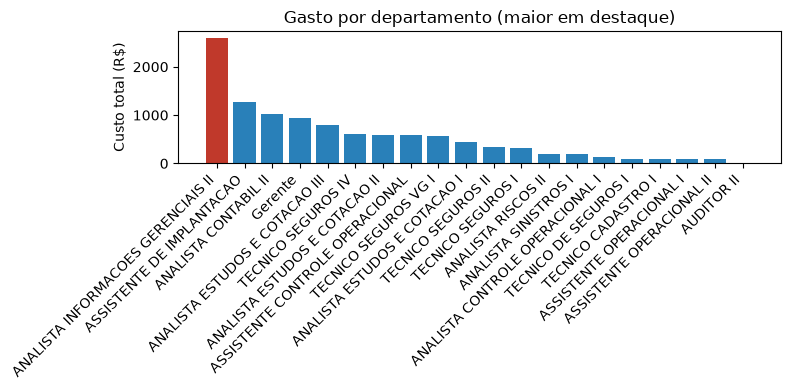

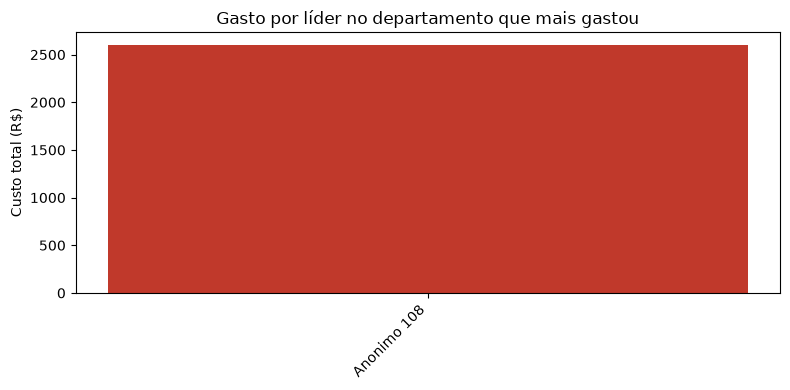

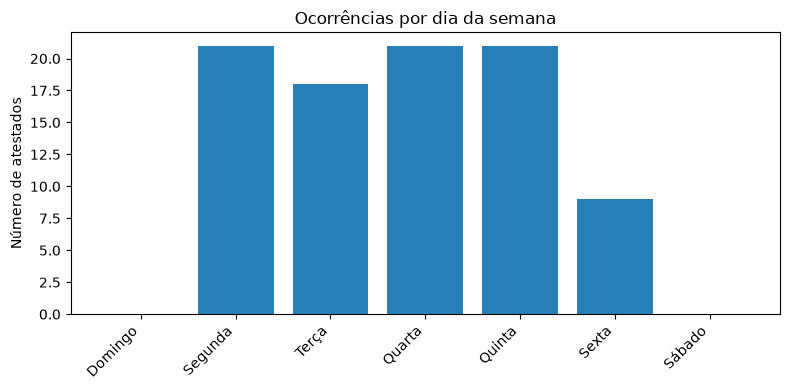

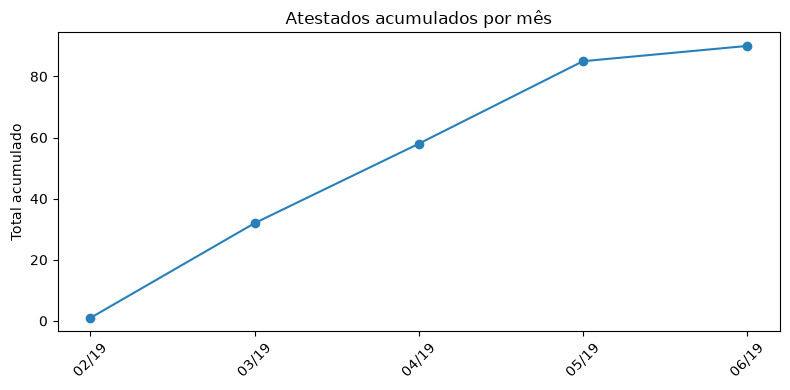

gráficos salvos


In [8]:
import os
import matplotlib.pyplot as plt


def bar_com_destaque(df, x_col, y_col, titulo, ylabel, arquivo):
    cores = ["#c0392b"] + ["#2980b9"] * (len(df) - 1)
    plt.figure(figsize=(8, 4))
    plt.bar(df[x_col], df[y_col], color=cores)
    plt.title(titulo)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(arquivo)
    plt.show()


def bar_simples(df, x_col, y_col, titulo, ylabel, arquivo):
    # dias_df é ordenado por dia da semana, não por valor — não faz sentido
    # destacar o índice 0 como "maior" aqui, então usamos uma cor única.
    plt.figure(figsize=(8, 4))
    plt.bar(df[x_col], df[y_col], color="#2980b9")
    plt.title(titulo)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(arquivo)
    plt.show()


# Pergunta 1: qual departamento gastou mais em afastamentos
bar_com_destaque(
    departamento_ranking_df, "departamento", "total_gasto",
    "Gasto por departamento (maior em destaque)", "Custo total (R$)",
    "gasto_departamento.png",
)

# Pergunta 2: quem é o líder do departamento que mais gastou
bar_com_destaque(
    lider_ranking_df, "lider", "gasto_sob_esse_lider",
    "Gasto por líder no departamento que mais gastou", "Custo total (R$)",
    "gasto_lider.png",
)

# Pergunta 3: ocorrências por dia da semana
bar_simples(
    dias_df, "dia_da_semana", "total_ocorrencias",
    "Ocorrências por dia da semana", "Número de atestados",
    "dia_semana.png",
)

# Pergunta 4: atestados acumulados ao longo do tempo (mês)
plt.figure(figsize=(8, 4))
plt.plot(acumulado_df["mes"], acumulado_df["acumulado"], marker="o", color="#2980b9")
plt.title("Atestados acumulados por mês")
plt.ylabel("Total acumulado")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("acumulado_mensal.png")
plt.show()

for arquivo in ("gasto_departamento.png", "gasto_lider.png", "dia_semana.png", "acumulado_mensal.png"):
    assert os.path.exists(arquivo)
print("gráficos salvos")